# Netflix Data Analysis

## Project Overview

#### This project analyzes Netflix movies and TV shows data to understand:
	•	Content distribution between Movies and TV Shows
	•	Growth of Netflix content over the years
	•	Popular genres available on the platform
	•	Countries producing the most Netflix content
	•	Content ratings and duration patterns

#### The analysis includes data cleaning, exploratory data analysis (EDA), and visualization to extract meaningful insights from the dataset.

## Dataset Preview – Insight

### The dataset contains Netflix content details, including:
	•	Show ID
	•	Title
	•	Type (Movie or TV Show)
	•	Director
	•	Cast
	•	Country
	•	Release Year
	•	Rating
	•	Duration
	•	Genre

### This dataset enables analysis of:
	•	Content distribution – understanding the ratio of Movies vs TV Shows
	•	Content trends – analyzing how Netflix content has grown over time
	•	Genre popularity – identifying the most common genres
	•	Country contribution – determining which countries produce the most Netflix content
	•	Rating patterns – understanding audience target groups


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [3]:
print(df.head())
df.columns = df.columns.str.strip()

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

# 1. Exploratory Data Analysis
## 1.1	What is the most common genre on Netflix?

### Objective

#### The goal of this analysis is to identify the most frequent genres available on Netflix and understand which types of content dominate the platform.

In [4]:
genre_counts = df['listed_in'].value_counts()
genre_counts.head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

Text(0, 0.5, 'Genre')

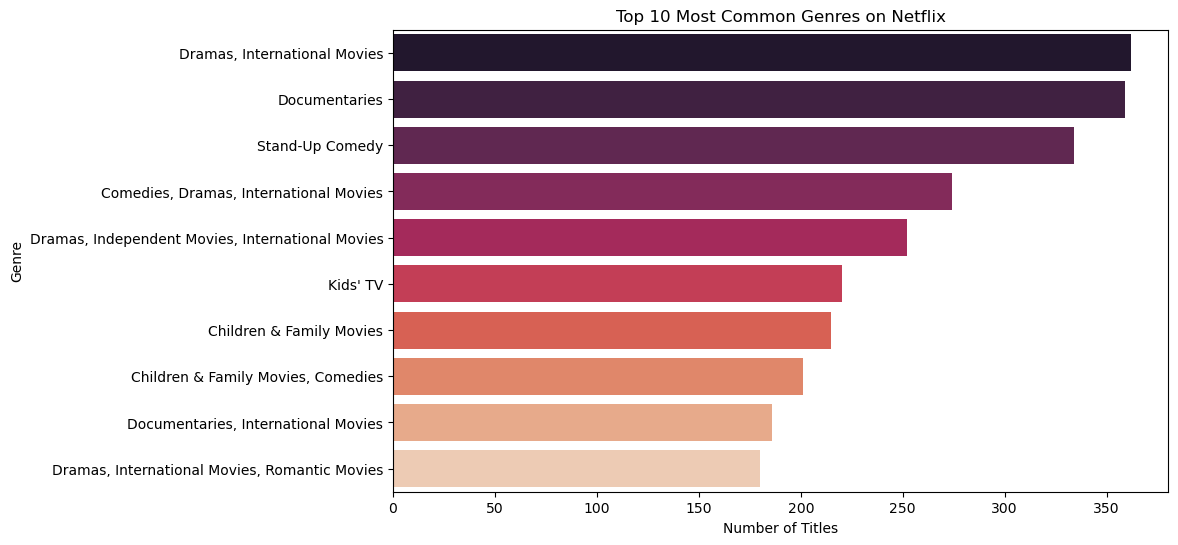

In [110]:
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, legend=False, palette="rocket")

plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

### Insight

#### The analysis shows that Drama, International Movies, and Comedies are among the most common genres on Netflix, indicating that the platform focuses heavily on entertainment and globally appealing content.

## 1.2 Which country produces the most Netflix content?



### Objective
#### To determine which country contributes the highest number of movies and TV shows to Netflix.

In [6]:
country_counts = df["country"].value_counts()
country_counts.head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Text(0, 0.5, 'Country')

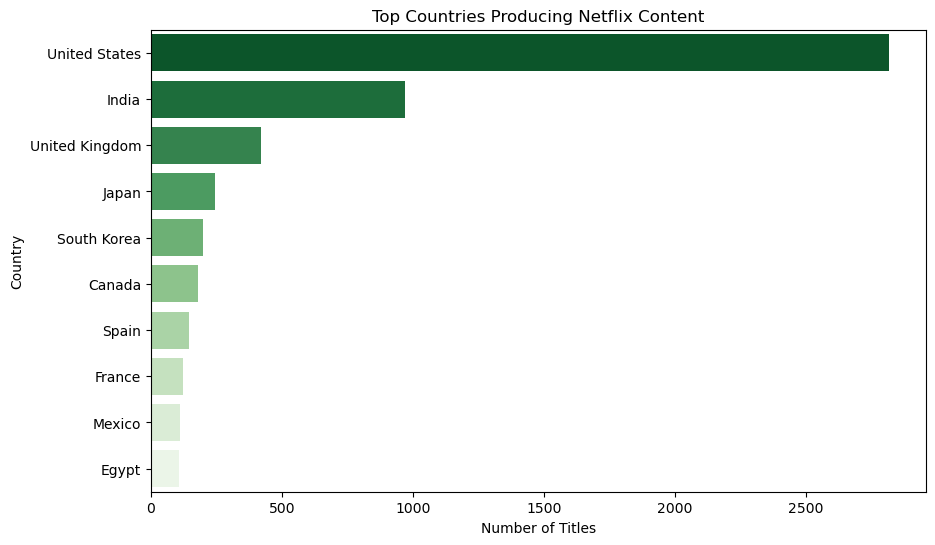

In [245]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='Greens_r')

plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

### Insight
##### The analysis reveals that the United States contributes the largest amount of content, followed by countries like India and the United Kingdom, showing Netflix’s strong presence in these regions.

## 1.3. What is the distribution of Movies vs TV Shows?

### Objective
#### To examine how Netflix content is divided between Movies and TV Shows.

In [8]:
type_counts = df["type"].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Text(0, 0.5, 'Number of Titles')

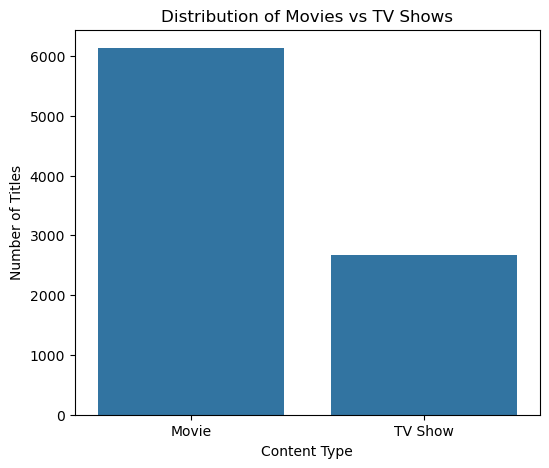

In [76]:
plt.figure(figsize=(6,5))
sns.countplot(x='type', data=df)

plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

### Insight
#### The results show that Movies dominate the Netflix catalog, indicating that Netflix hosts more films than television series.

## 1.4. Which release year has the highest number of titles?

### Objective
#### To analyze content release trends and identify the year with the highest number of titles added to Netflix.

In [77]:
year_counts = df["release_year"].value_counts().sort_index()
year_counts

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

Text(0, 0.5, 'Number of Titles')

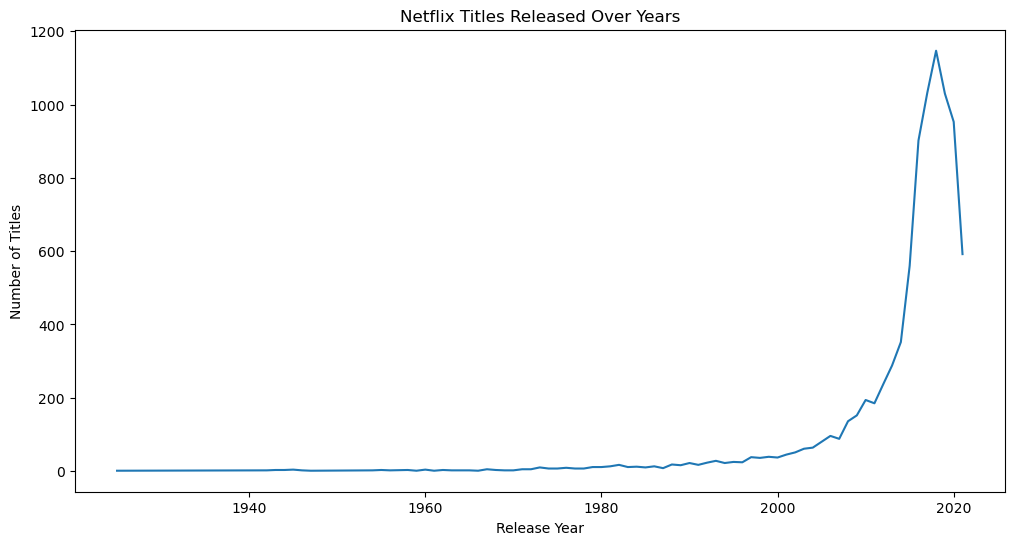

In [78]:
plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Netflix Titles Released Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

### Insight
#### The analysis indicates that recent years have the highest number of releases, reflecting Netflix’s expansion and increased content production.

## 1.5. Which rating category appears most frequently?

### Objective
#### To analyze the distribution of content ratings and understand the primary audience targeted by Netflix.

In [12]:
rating_counts = df['rating'].value_counts()
rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Text(0, 0.5, 'Rating')

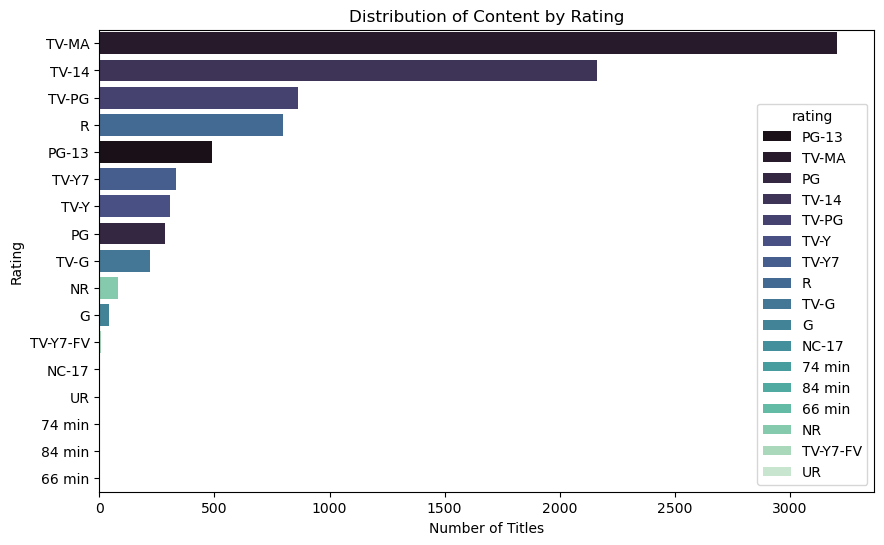

In [248]:
plt.figure(figsize=(10,6))
sns.countplot(y='rating', hue='rating', data=df, order=df['rating'].value_counts().index, palette="mako")

plt.title("Distribution of Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

### Insight
#### The analysis shows that TV-MA and TV-14 ratings are the most common, suggesting that Netflix primarily targets teen and adult audiences.

## 1.6. What are the top 10 longest duration movies or shows?

### Objective
#### To identify the movies or TV shows with the longest duration in the dataset.

In [80]:
duration_counts = df['duration'].value_counts().head(10)
duration_counts

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

Text(0, 0.5, 'Duration')

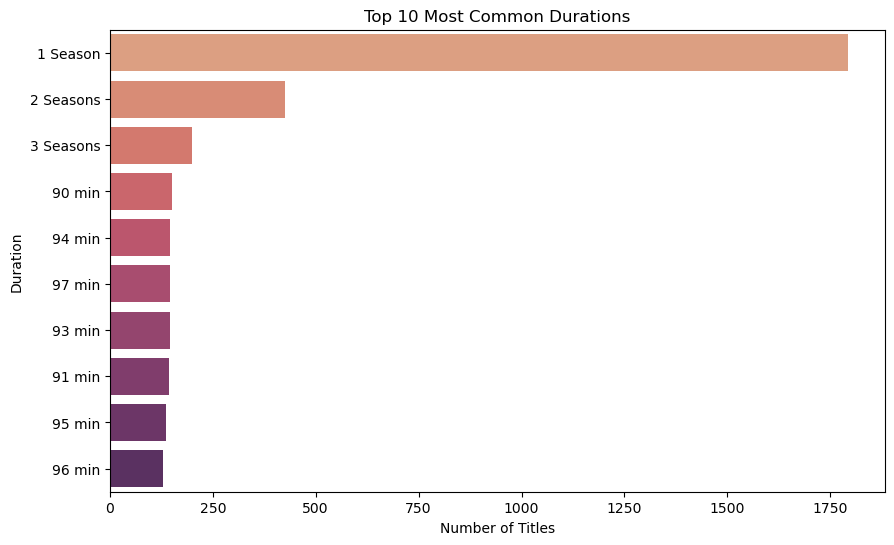

In [249]:
plt.figure(figsize=(10,6))
sns.barplot(x=duration_counts.values, y=duration_counts.index, hue=duration_counts.index, palette="flare")

plt.title("Top 10 Most Common Durations")
plt.xlabel("Number of Titles")
plt.ylabel("Duration")

### Insight
#### The analysis reveals that some movies or TV shows have significantly longer durations than average, highlighting long-format content available on Netflix.

# 2. Analysis in Terms of Content Distribution

## 2.1. Which country has the highest number of movies and TV shows?

### Objective
#### To analyze the distribution of Netflix content across different countries.

In [84]:
country_counts = df.groupby('country')['type'].value_counts()
country_counts

country                                              type   
, France, Algeria                                    Movie       1
, South Korea                                        TV Show     1
Argentina                                            Movie      38
                                                     TV Show    18
Argentina, Brazil, France, Poland, Germany, Denmark  Movie       1
                                                                ..
Venezuela                                            Movie       1
Venezuela, Colombia                                  Movie       1
Vietnam                                              Movie       7
West Germany                                         Movie       1
Zimbabwe                                             Movie       1
Name: count, Length: 847, dtype: int64

Text(0, 0.5, 'Country')

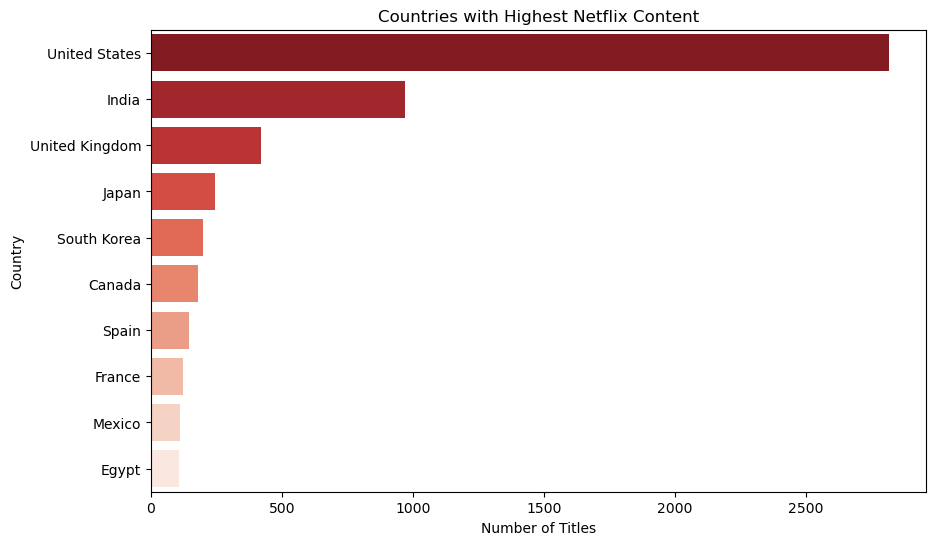

In [250]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette="Reds_r")

plt.title("Countries with Highest Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

### Insight
#### The results show that the United States leads in the number of movies and TV shows, indicating its dominant role in Netflix content production.

## 2.2. Which genre dominates Netflix content?

### Objective
#### To determine which genre category appears most frequently in the Netflix catalog.

In [91]:
genre_counts = df['listed_in'].value_counts().head(10)
genre_counts

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

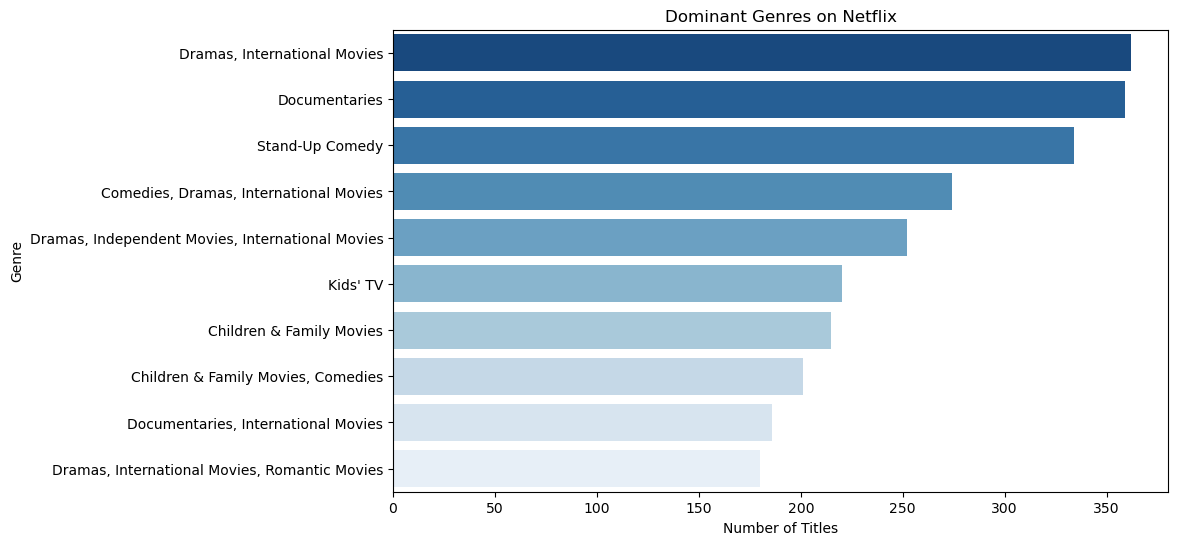

In [251]:
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette="Blues_r")

plt.title("Dominant Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Insight
#### The analysis indicates that Drama-related genres dominate Netflix content, showing a strong preference for storytelling and narrative-driven entertainment.

## 2.3. Which year had the highest content release?

### Objective
#### To identify the year in which Netflix added the highest number of titles.

In [93]:
year_counts = df['release_year'].value_counts().sort_index()
year_counts

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

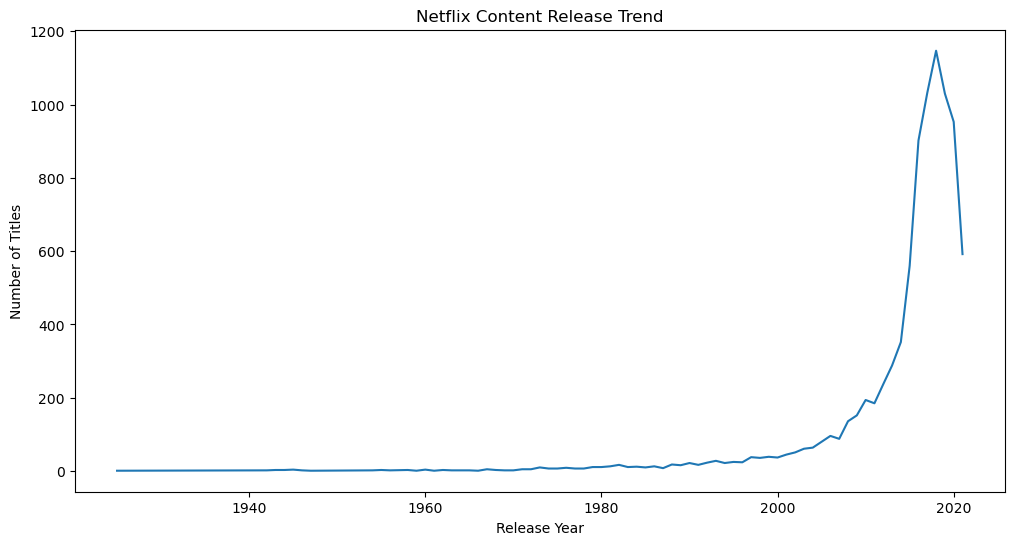

In [94]:
plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Insight
#### The results show that recent years have experienced the highest content releases, reflecting Netflix’s aggressive expansion strategy.

## 2.4. Which rating category has the most content?

### Objective
#### To understand the distribution of content ratings across Netflix titles.

In [97]:
rating = df['rating'].value_counts()
rating

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'PG-13'),
  Text(1, 0, 'TV-MA'),
  Text(2, 0, 'PG'),
  Text(3, 0, 'TV-14'),
  Text(4, 0, 'TV-PG'),
  Text(5, 0, 'TV-Y'),
  Text(6, 0, 'TV-Y7'),
  Text(7, 0, 'R'),
  Text(8, 0, 'TV-G'),
  Text(9, 0, 'G'),
  Text(10, 0, 'NC-17'),
  Text(11, 0, '74 min'),
  Text(12, 0, '84 min'),
  Text(13, 0, '66 min'),
  Text(14, 0, 'NR'),
  Text(15, 0, 'TV-Y7-FV'),
  Text(16, 0, 'UR')])

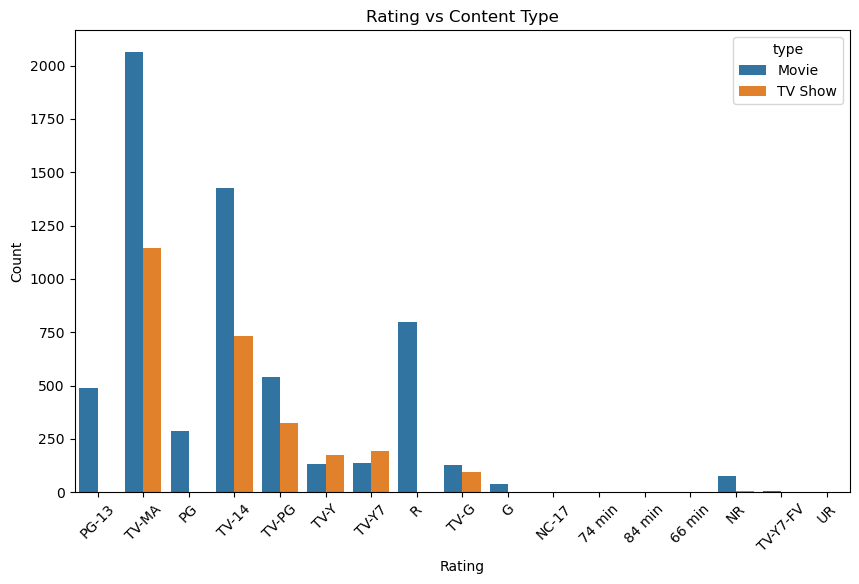

In [98]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating', hue='type', data=df)

plt.title("Rating vs Content Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)

### Insight
#### The analysis shows that TV-MA has the largest share, indicating a large amount of mature or adult-oriented content.

## 2.5. Which type of content dominates Netflix?

### Objective
#### To compare the number of Movies and TV Shows on Netflix.

In [68]:
content_type = df['type'].value_counts()
content_type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Text(0, 0.5, 'Number of Titles')

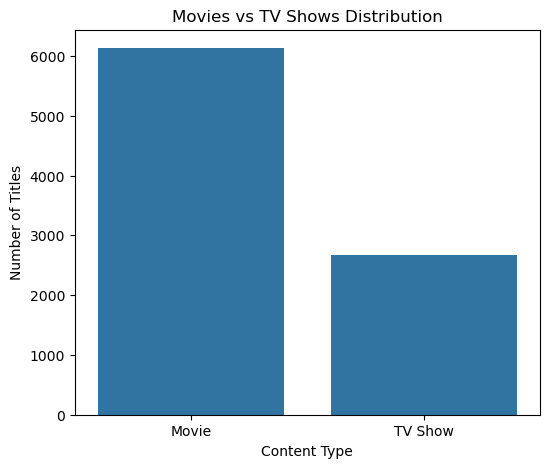

In [99]:
plt.figure(figsize=(6,5))
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

### Insight
#### The results indicate that Movies are more numerous than TV Shows, highlighting Netflix’s focus on film content.

# 3. Bivariate Analysis

## 3.1. Content Type vs Release Year

### Objective
#### To analyze how the number of movies and TV shows has changed across different release years.

In [115]:
type_year = df.groupby(['release_year','type']).size().reset_index(name='counts')
type_year

,release_year,type,counts
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3
...,...,...,...
114,2019,TV Show,397
115,2020,Movie,517
116,2020,TV Show,436
117,2021,Movie,277


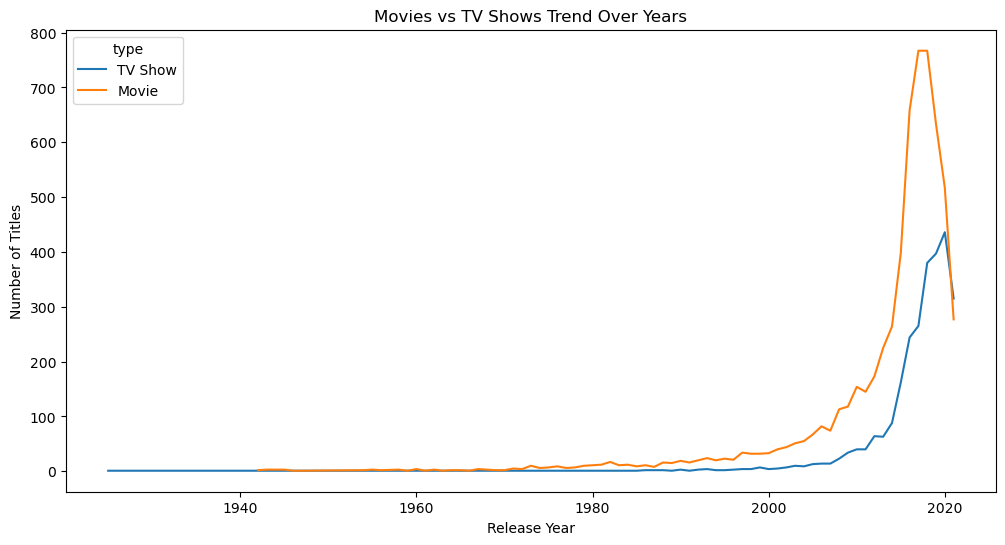

In [117]:
plt.figure(figsize=(12,6))
sns.lineplot(data=type_year, x='release_year', y='counts', hue='type')

plt.title("Movies vs TV Shows Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

### Insight
#### The analysis shows that both movies and TV shows increased significantly in recent years, with movies maintaining a higher overall count.

## 3.2. Country vs Genre Distribution

### Objective
#### To understand how different countries contribute to various genres on Netflix.

In [255]:
country_genre = df.groupby(['country','listed_in']).size().reset_index(name='count')
country_genre

,country,listed_in,count
0,", France, Algeria","Dramas, Independent Movies, International Movies",1
1,", South Korea","International TV Shows, TV Dramas",1
2,Argentina,"Action & Adventure, Comedies, International Mo...",1
3,Argentina,"Action & Adventure, Horror Movies, Internation...",1
4,Argentina,"Children & Family Movies, Music & Musicals",1
...,...,...,...
2639,Vietnam,"Dramas, International Movies",1
2640,Vietnam,"Dramas, International Movies, Romantic Movies",1
2641,Vietnam,"Horror Movies, International Movies, Thrillers",1
2642,West Germany,"Documentaries, International Movies",1


Text(0, 0.5, 'Country')

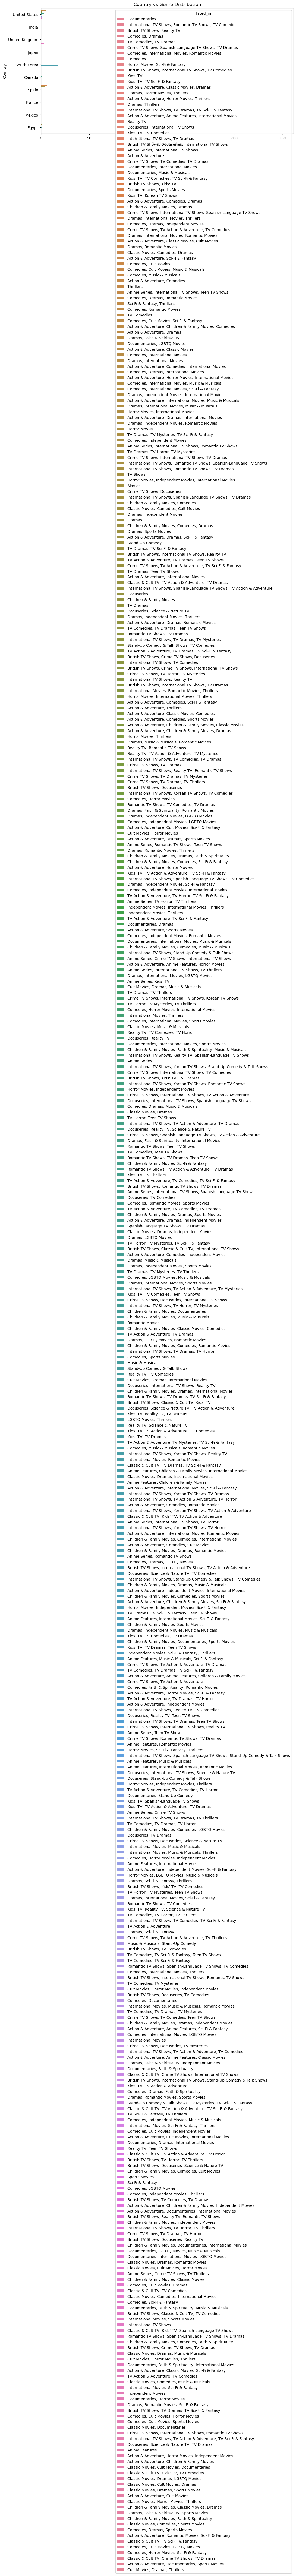

In [259]:
top_countries = df['country'].value_counts().head(10).index
filtered_df = df[df['country'].isin(top_countries)]

plt.figure(figsize=(12,6))

sns.countplot(y='country', hue='listed_in', data=filtered_df,
              order=top_countries)
              

plt.title("Country vs Genre Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

### Insight
#### The results reveal that different countries specialize in different genres, reflecting regional preferences and production trends.

## 3.3. Rating vs Content Type

### Objective
#### To analyze how content ratings differ between movies and TV shows.

In [169]:
content_rating = df.groupby(['country','rating']).size().reset_index(name='count')
content_rating

,country,rating,count
0,", France, Algeria",TV-14,1
1,", South Korea",TV-MA,1
2,Argentina,NR,2
3,Argentina,R,1
4,Argentina,TV-14,7
...,...,...,...
1170,Vietnam,TV-14,3
1171,Vietnam,TV-G,1
1172,Vietnam,TV-MA,3
1173,West Germany,TV-MA,1


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'PG-13'),
  Text(1, 0, 'TV-MA'),
  Text(2, 0, 'PG'),
  Text(3, 0, 'TV-14'),
  Text(4, 0, 'TV-PG'),
  Text(5, 0, 'TV-Y'),
  Text(6, 0, 'TV-Y7'),
  Text(7, 0, 'R'),
  Text(8, 0, 'TV-G'),
  Text(9, 0, 'G'),
  Text(10, 0, 'NC-17'),
  Text(11, 0, '74 min'),
  Text(12, 0, '84 min'),
  Text(13, 0, '66 min'),
  Text(14, 0, 'NR'),
  Text(15, 0, 'TV-Y7-FV'),
  Text(16, 0, 'UR')])

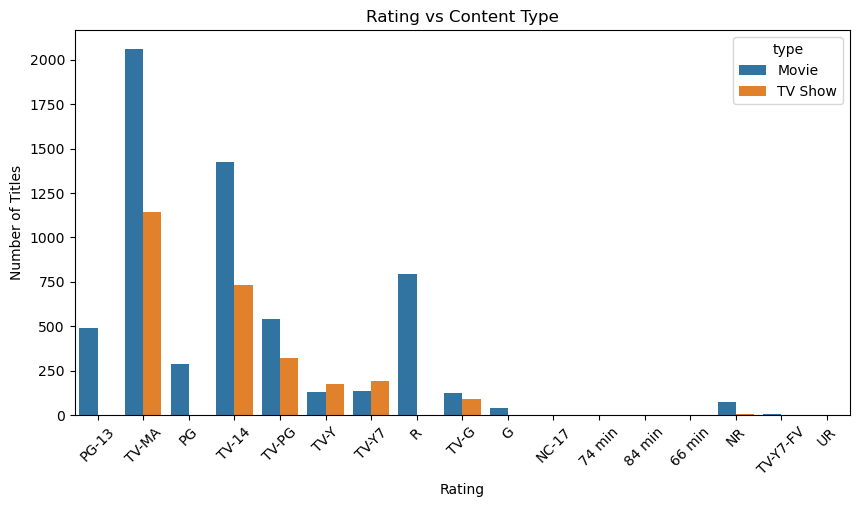

In [170]:
plt.figure(figsize=(10,5))

sns.countplot(x='rating', hue='type', data=df)
plt.title("Rating vs Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

### Insight
#### The analysis indicates that TV Shows often fall under TV-MA or TV-14 ratings, while movies have a wider distribution across ratings.

## 3.4. Release Year vs Number of Shows

### Objective
#### To examine how the number of titles released varies over the years.

In [171]:
year_counts = df['release_year'].value_counts().sort_index()
year_counts

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

Text(0, 0.5, 'Number of Titles')

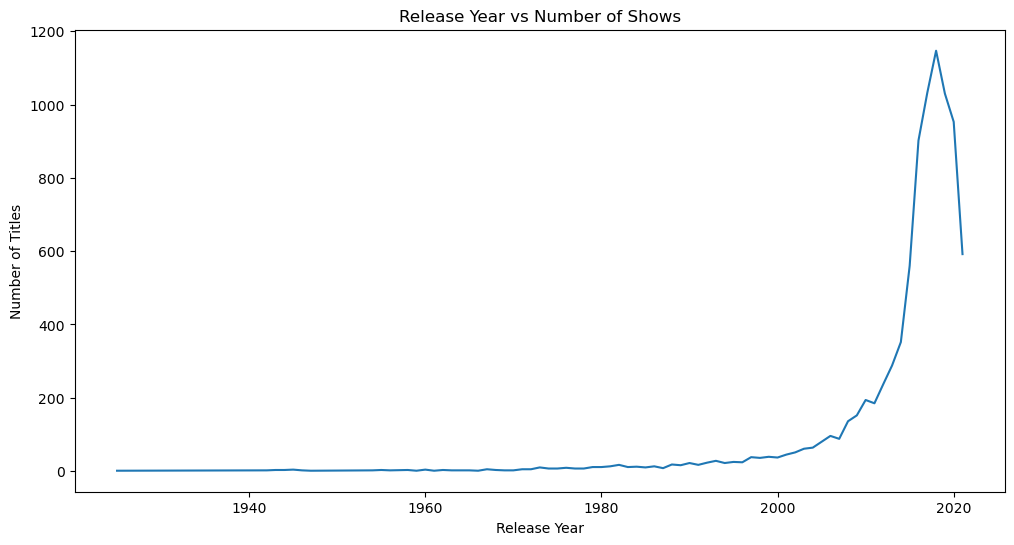

In [172]:
plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Release Year vs Number of Shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

### Insight
#### The results show a steady increase in content releases over time, demonstrating Netflix’s rapid growth.

## 3.5. Genre vs Content Type

### Objective
#### To compare how genres are distributed between movies and TV shows.

In [191]:
content_genre = df['listed_in'].value_counts().sort_index()
content_genre

listed_in
Action & Adventure                                              128
Action & Adventure, Anime Features                                1
Action & Adventure, Anime Features, Children & Family Movies      4
Action & Adventure, Anime Features, Classic Movies                2
Action & Adventure, Anime Features, Horror Movies                 1
                                                               ... 
TV Horror, TV Mysteries, Teen TV Shows                            1
TV Horror, Teen TV Shows                                          2
TV Sci-Fi & Fantasy, TV Thrillers                                 1
TV Shows                                                         16
Thrillers                                                        65
Name: count, Length: 514, dtype: int64

Text(0, 0.5, 'Genre')

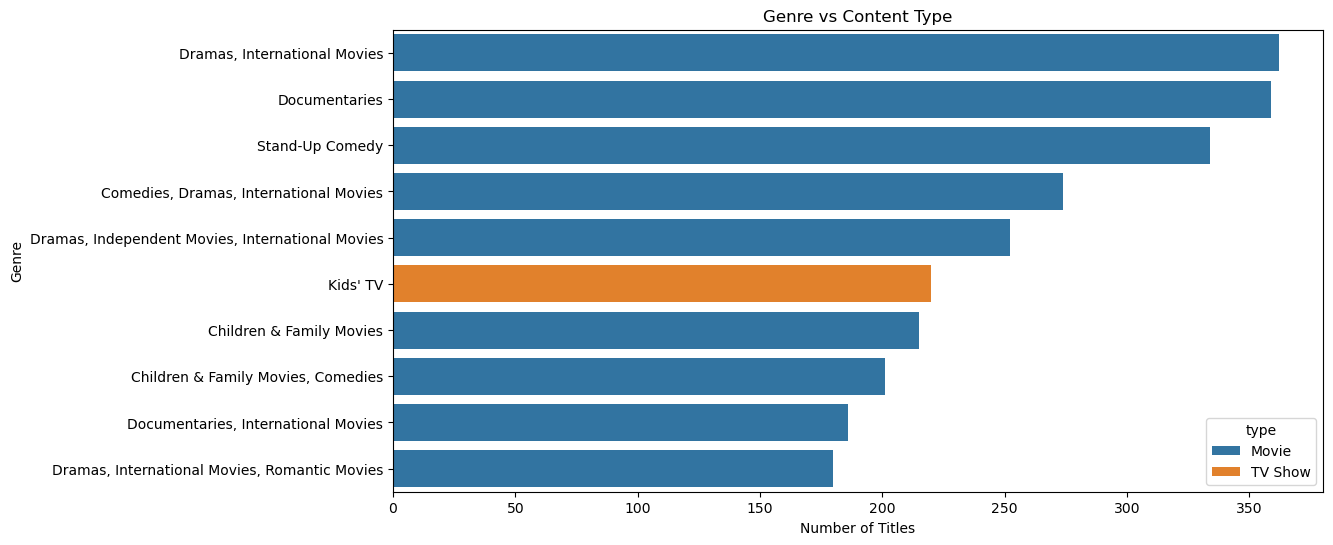

In [192]:
plt.figure(figsize=(12,6))

sns.countplot(y='listed_in', hue='type', data=df, order=df['listed_in'].value_counts().head(10).index)

plt.title("Genre vs Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

### Insight
#### The analysis shows that some genres are more dominant in movies, while others appear frequently in TV series.

# 4. Multivariate Analysis

## 4.1. Country vs Genre vs Release Year

### Objective
#### To analyze how different countries produce specific genres over different years.

In [229]:
country_genre_year = df.groupby(['country','release_year']).size().reset_index(name='count').head(20)
country_genre_year

,country,release_year,count
0,", France, Algeria",2014,1
1,", South Korea",2021,1
2,Argentina,1985,2
3,Argentina,1998,1
4,Argentina,2004,1
5,Argentina,2006,1
6,Argentina,2007,1
7,Argentina,2015,4
8,Argentina,2016,7
9,Argentina,2017,4


Text(145.7222222222222, 0.5, 'Country')

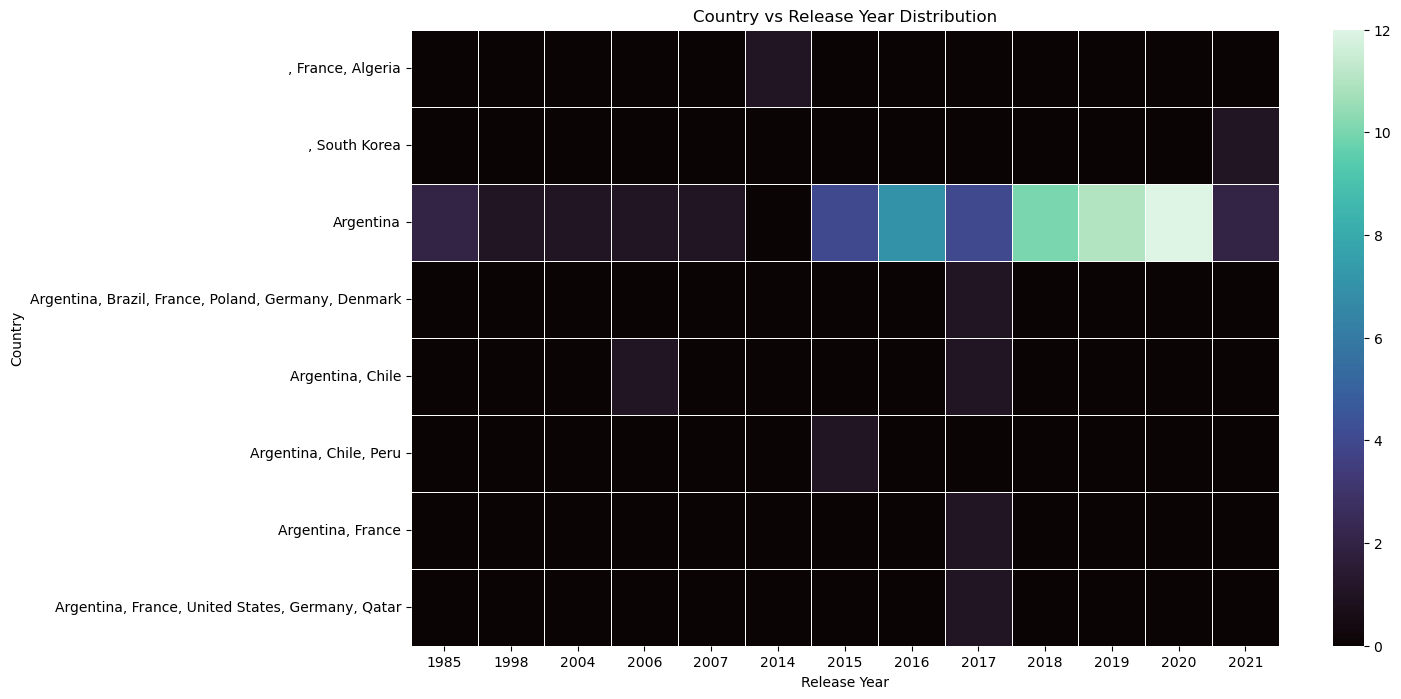

In [231]:
pivot_table = country_genre_year.pivot(index='country', columns='release_year', values='count')

plt.figure(figsize=(14,8))

sns.heatmap(pivot_table.fillna(0), cmap="mako", linewidths=0.5)

plt.title("Country vs Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Country")

### Insight
#### The results show that certain countries consistently produce particular genres, while content production has increased significantly in recent years.

## 4.2. Genre vs Rating vs Content Type

### Objective
#### To examine relationships between genres, ratings, and types of content.

In [233]:
genre_rating_type = df.groupby(['listed_in','rating','type']).size().reset_index(name='count')
genre_rating_type.head(10)

,listed_in,rating,type,count
0,Action & Adventure,PG-13,Movie,23
1,Action & Adventure,R,Movie,86
2,Action & Adventure,TV-14,Movie,2
3,Action & Adventure,TV-MA,Movie,17
4,"Action & Adventure, Anime Features",TV-MA,Movie,1
5,"Action & Adventure, Anime Features, Children &...",PG,Movie,1
6,"Action & Adventure, Anime Features, Children &...",TV-14,Movie,1
7,"Action & Adventure, Anime Features, Children &...",TV-PG,Movie,2
8,"Action & Adventure, Anime Features, Classic Mo...",PG-13,Movie,1
9,"Action & Adventure, Anime Features, Classic Mo...",TV-14,Movie,1


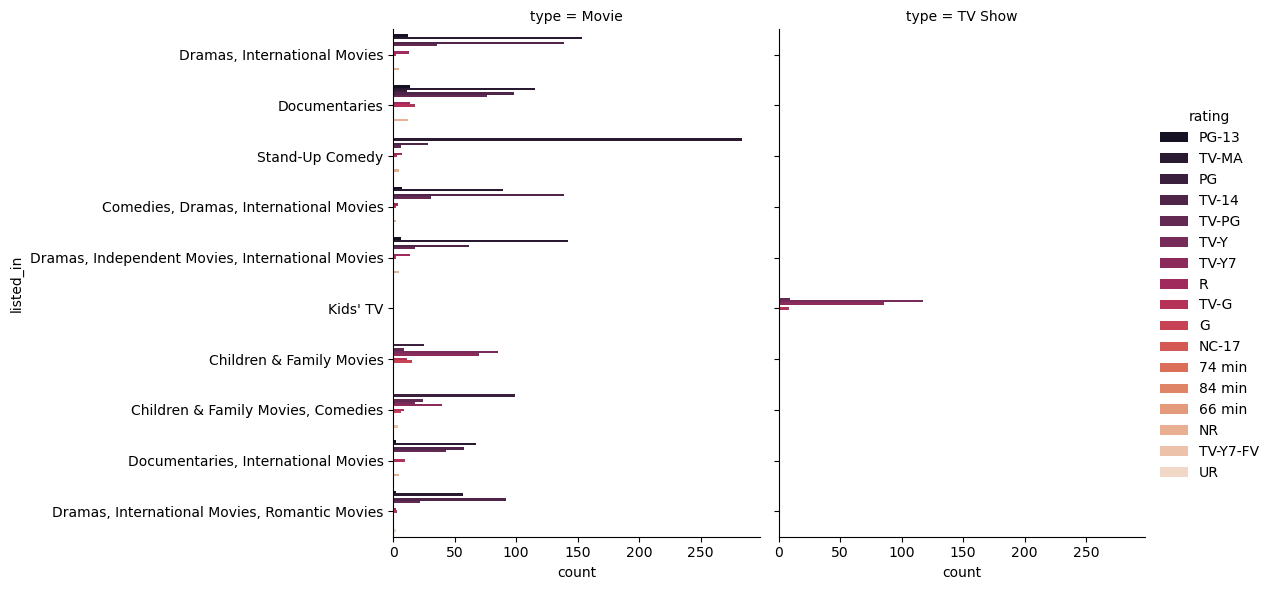

In [234]:
sns.catplot(
    data=df,
    kind="count",
    y="listed_in",
    hue="rating",
    col="type",
    order=df['listed_in'].value_counts().head(10).index,
    height=6,
    aspect=1,
    palette="rocket"
)

plt.show()

### Insight
#### The analysis shows that some genres are associated with specific rating categories and content types, indicating audience targeting strategies.

## 4.3. Content Growth Across Years and Countries

### Objective
#### To analyze how Netflix content has expanded across different countries over time.

In [241]:
top_countries = df['country'].value_counts().head().index
filtered_df = df[df['country'].isin(top_countries)]

country_year = (
    filtered_df.groupby(['release_year', 'country']).size().reset_index(name='count')
)

country_year.head(10)

,release_year,country,count
0,1942,United States,2
1,1943,United States,3
2,1944,United States,2
3,1945,United States,4
4,1946,United States,2
5,1947,United States,1
6,1954,United States,1
7,1955,United States,1
8,1956,United States,1
9,1958,United States,2


Text(0, 0.5, 'Number of Titles')

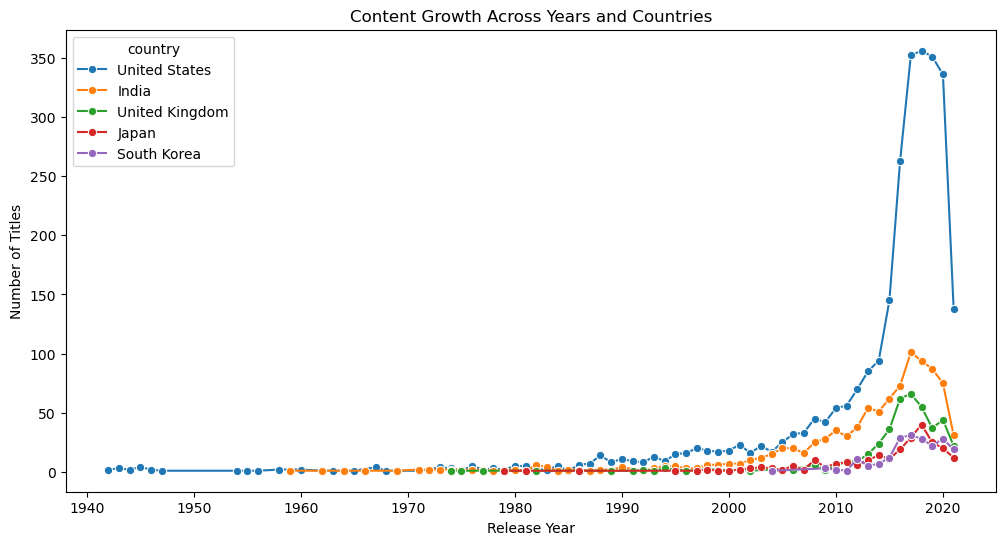

In [242]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=country_year,
    x='release_year',
    y='count',
    hue='country',
    marker='o'
)

plt.title("Content Growth Across Years and Countries")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

### Insight
#### The analysis reveals that Netflix has expanded globally, with increasing contributions from multiple countries in recent years.

# Project Conclusion

**Summary of Analysis:** 

This project performed ETL and exploratory data analysis on the Netflix dataset to examine patterns in **content distribution, genre popularity, production trends, and audience targeting**. Data cleaning and visualization techniques were applied to extract meaningful insights from the dataset.

**Key Findings:** 

The analysis showed that **movies make up a larger portion of the Netflix catalog compared to TV shows**. Genres such as drama, international movies, and comedy appear most frequently, indicating Netflix’s focus **on widely appealing content**. The **United States contributes the highest number of titles**, followed by other major production regions. Additionally, content releases increased significantly in recent years, reflecting Netflix’s growth and expansion.

**Overall Insight:** 

The results highlight how data analysis can **help understand content trends, production patterns, and audience focus in streaming platforms**. These insights demonstrate the importance of data-driven approaches in evaluating digital entertainment platforms and their content strategies.